# Sistem Rekomendasi

# Pengumpulan Data

In [107]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

df_usda = pd.read_excel("usda.xlsx")



# EDA Sebelum Pre-Processing

Struktur Dataset Sebelum Pre-Processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4993 entries, 0 to 4992
Data columns (total 47 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FoodID            4993 non-null   int64  
 1   FoodCategory      4993 non-null   object 
 2   FoodName          4993 non-null   object 
 3   Air               4992 non-null   float64
 4   Energi            4958 non-null   float64
 5   Protein           4832 non-null   float64
 6   Lemak             4723 non-null   float64
 7   Abu               4647 non-null   float64
 8   Karbohidrat       4298 non-null   float64
 9   Serat             3197 non-null   float64
 10  GulaTotal         3235 non-null   float64
 11  Kalsium           4583 non-null   float64
 12  Besi              4773 non-null   float64
 13  Magnesium         4509 non-null   float64
 14  Fosfor            4539 non-null   float64
 15  Kalium            4755 non-null   float64
 16  N

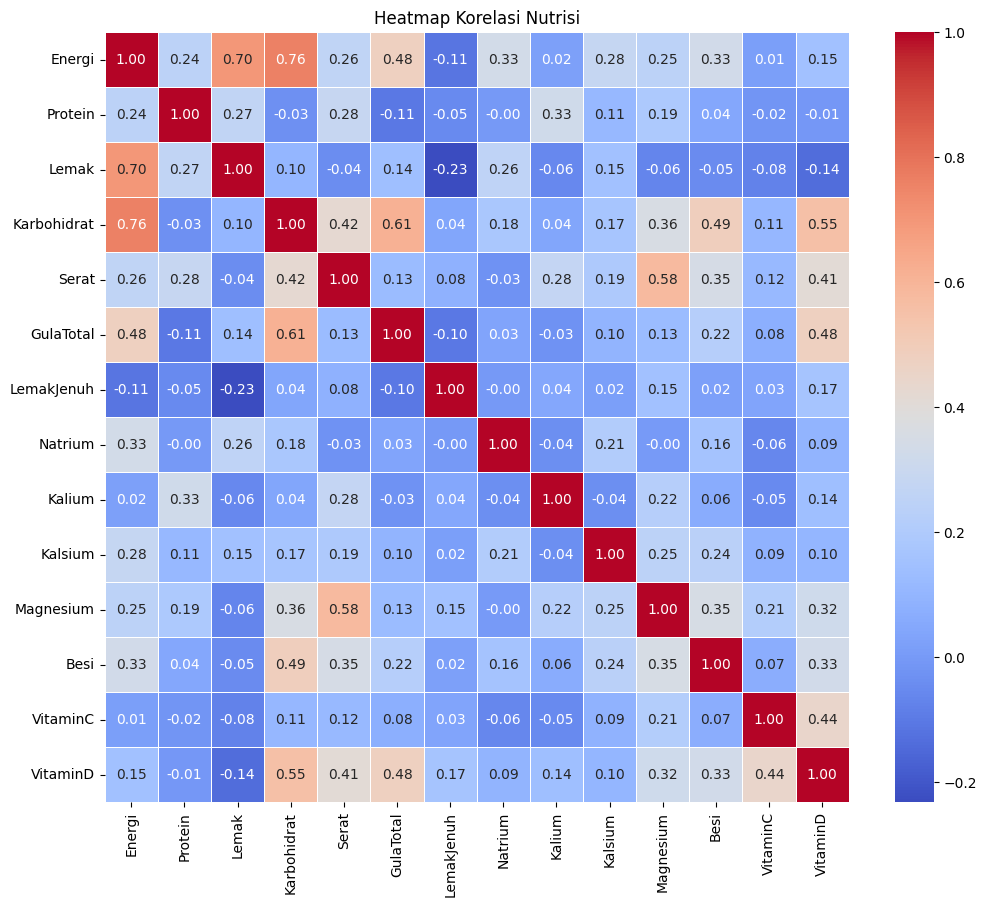

In [108]:
# Melihat struktur dataset
print("Struktur Dataset Sebelum Pre-Processing:")
print(df_usda.info())

# Melihat jumlah data dan kolom
print("\nBentuk Dataset Sebelum Pre-Processing:", df_usda.shape)

# Melihat beberapa data awal
print("\nSample Data Sebelum Pre-Processing:")
print(df_usda.head())

# Melihat statistik deskriptif
print("\nStatistik Deskriptif Sebelum Pre-Processing:")
print(df_usda.describe())

# Melihat nilai yang hilang
print("\nJumlah Nilai yang Hilang per Kolom Sebelum Pre-Processing:")
print(df_usda.isnull().sum())

# Melihat duplikat data
print("\nJumlah Duplikat Data Sebelum Pre-Processing:",df_usda.duplicated().sum())

# Melihat duplikat berdasarkan FoodID
print("\nJumlah Duplikat Berdasarkan FoodID Sebelum Pre-Processing:", df_usda.duplicated(subset=['FoodID']).sum())

# Melihat duplikat berdasarkan FoodName
print("\nJumlah Duplikat Berdasarkan FoodName Sebelum Pre-Processing:", df_usda.duplicated(subset=['FoodName']).sum())

print("Data duplikat berdasarkan 'FoodName':")
print(df_usda[df_usda.duplicated(subset=['FoodName'], keep=False)])

# Melihat distribusi kategori makanan
print("\nDistribusi Kategori Makanan Sebelum Pre-Processing:")
print(df_usda['FoodCategory'].value_counts())

# Melihat heatmap korelasi nutrisi
num_col = [
    'Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
    'GulaTotal', 'LemakJenuh',
    'Natrium', 'Kalium', 'Kalsium', 'Magnesium',
    'Besi', 'VitaminC', 'VitaminD']
correlation_matrix = df_usda[num_col].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Nutrisi')
plt.show()

# Pre-Processing Data

In [109]:
def preprocess_data(df):
    # Memilih makanan relevan
    df_clean = df[~df['FoodName'].str.contains( 'mentah|tidak siap|alkohol|babi|leavening|baking soda|baking powder|'
                                                'ragi|bir|keras|pengganti krim', case=False, na=False )].copy()
    df_clean = df_clean[df_clean['FoodCategory'] != 'Babi']

    # 2. Membuat kolom baru 'FoodGroup' berdasarkan 'FoodCategory'

    food_group_mapping = {
        'Daging dan Sosis': 'Makanan Utama',
        'Daging Merah dan Hasil Buruan': 'Makanan Utama',
        'Ikan dan Kerang': 'Makanan Utama',
        'Sereal dan Pasta': 'Makanan Utama',
        'Unggas': 'Makanan Utama',
        'Keju, Susu, dan Telur': 'Makanan Pendamping',
        'Makanan Pembuka dan Lauk': 'Makanan Pendamping',
        'Produk Panggang': 'Makanan Pendamping',
        'Sayuran': 'Makanan Pendamping',
        'Sup dan Kaldu': 'Makanan Pendamping',
        'Buah dan Jus': 'Minuman dan Buah',
        'Minuman': 'Minuman dan Buah'
    }
    df_clean['FoodGroup'] = df_clean['FoodCategory'].map(food_group_mapping)

    # Memindahkan kolom FoodGroup agar berada sebelum FoodName
    cols = df_clean.columns.tolist()
    food_name_idx = cols.index('FoodName')

    # Hapus FoodGroup dari posisi aslinya (jika sudah ada, yang seharusnya tidak jika baru dibuat)
    if 'FoodGroup' in cols:
        cols.remove('FoodGroup')
    # Masukkan FoodGroup pada posisi sebelum FoodName
    cols.insert(food_name_idx, 'FoodGroup')
    df_clean = df_clean[cols]

    # Mengisi nilai kosong dengan 0
    df_clean.fillna(0, inplace=True)

    # Menghapus duplikat berdasarkan FoodName
    df_clean = df_clean.drop_duplicates(subset=['FoodName'])

    # Memilih kolom yang akan digunakan
    selected_columns = [
            'FoodID', 'FoodCategory', 'FoodGroup', 'FoodName',
            'Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
            'GulaTotal', 'LemakJenuh',
            'Natrium', 'Kalium', 'Kalsium', 'Magnesium',
            'Besi', 'VitaminC', 'VitaminD'
    ]
    df_clean = df_clean[selected_columns]

    # Simpan salinan data asli sebelum normalisasi
    df_original = df_clean.copy()

    # Normalisasi data nutrisi
    non_numeric_cols = ['FoodID', 'FoodCategory', 'FoodGroup', 'FoodName']
    numeric_cols = [col for col in df_clean.columns if col not in non_numeric_cols]
    scaler = MinMaxScaler()
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

    return df_clean, scaler, df_original, numeric_cols

df_preprocessed, scaler, df_original, nutrient_cols = preprocess_data(df_usda)

# EDA Setelah Pre-Processing

Struktur Dataset Setelah Pre-Processing:
<class 'pandas.core.frame.DataFrame'>
Index: 4272 entries, 256 to 4992
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FoodID        4272 non-null   int64  
 1   FoodCategory  4272 non-null   object 
 2   FoodGroup     4272 non-null   object 
 3   FoodName      4272 non-null   object 
 4   Energi        4272 non-null   float64
 5   Protein       4272 non-null   float64
 6   Lemak         4272 non-null   float64
 7   Karbohidrat   4272 non-null   float64
 8   Serat         4272 non-null   float64
 9   GulaTotal     4272 non-null   float64
 10  LemakJenuh    4272 non-null   float64
 11  Natrium       4272 non-null   float64
 12  Kalium        4272 non-null   float64
 13  Kalsium       4272 non-null   float64
 14  Magnesium     4272 non-null   float64
 15  Besi          4272 non-null   float64
 16  VitaminC      4272 non-null   float64
 17  VitaminD      4272 non-null   flo

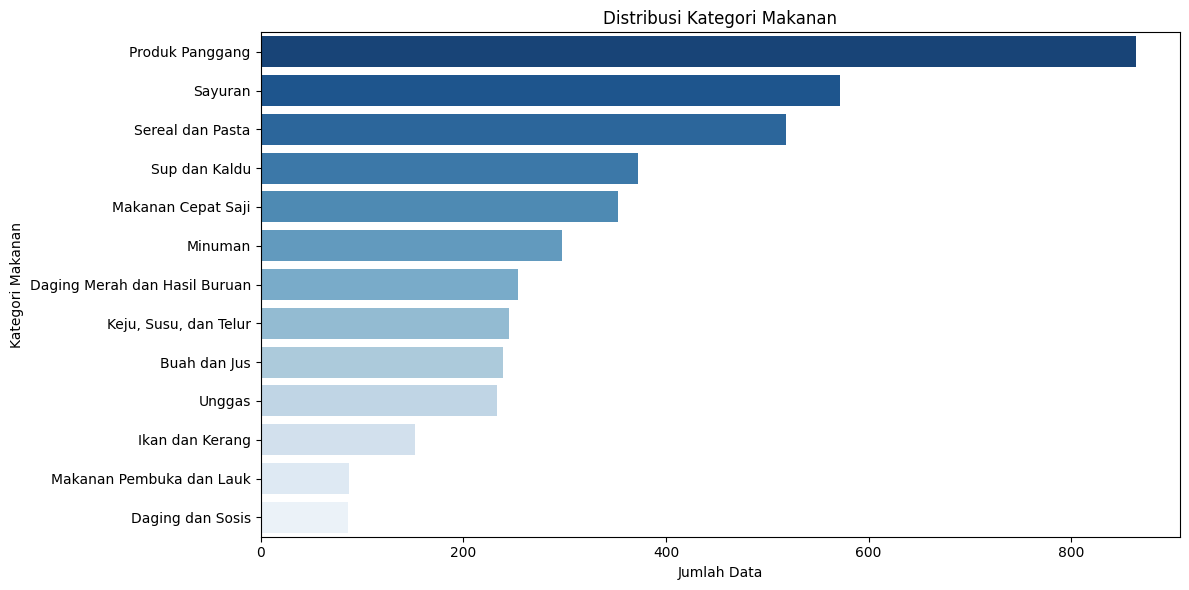

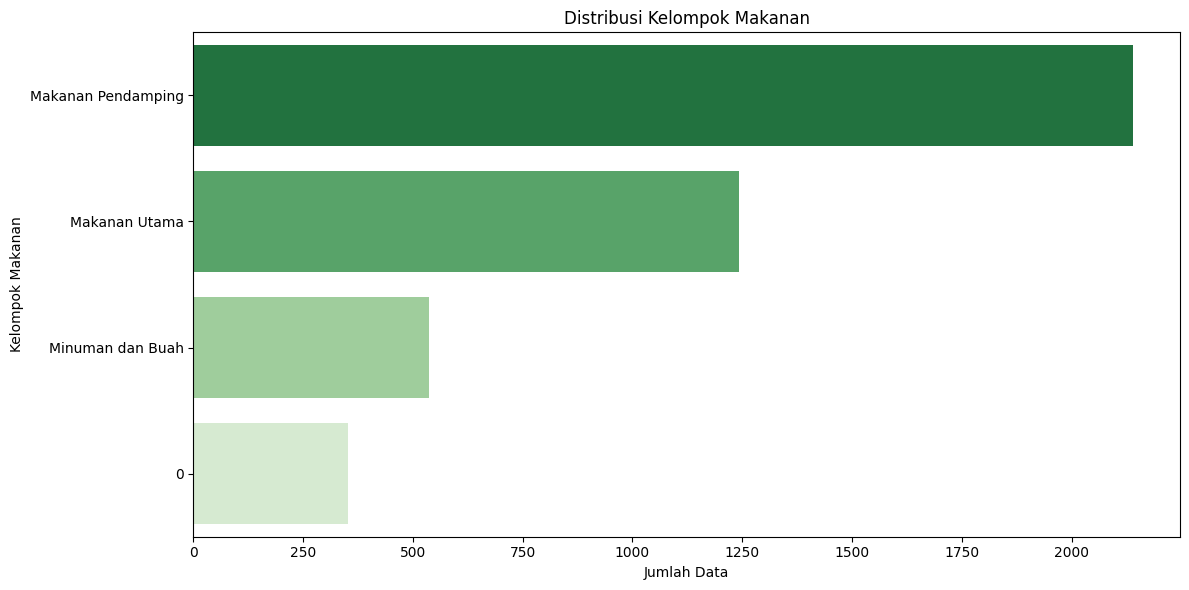

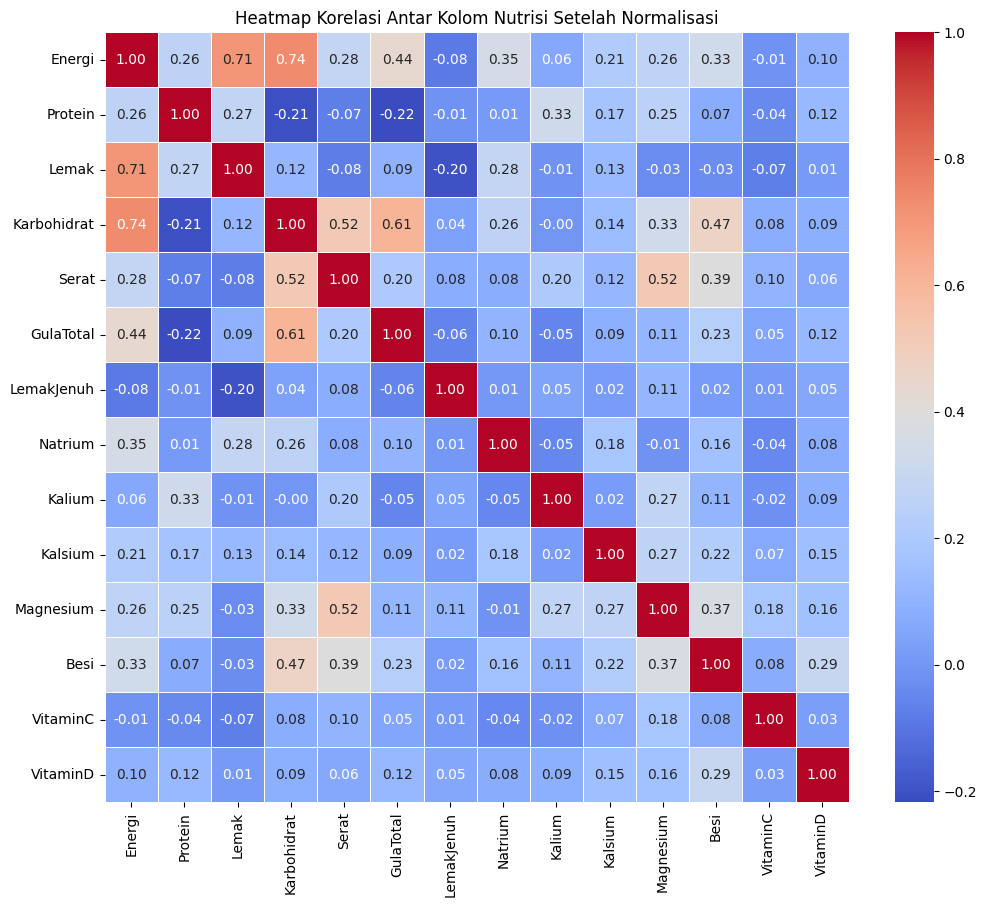

In [110]:
# Melihat struktur dataset setelah pre-processing
print("Struktur Dataset Setelah Pre-Processing:")
print(df_preprocessed.info())

# Melihat jumlah data dan kolom setelah pre-processing
print("\nBentuk Dataset Setelah Pre-Processing:", df_preprocessed.shape)

# Melihat beberapa data awal setelah pre-processing
print("\nSample Data Setelah Pre-Processing:")
print(df_preprocessed.head())

# Melihat statistik deskriptif setelah pre-processing
print("\nStatistik Deskriptif Setelah Pre-Processing:")
print(df_preprocessed.describe())

# Melihat statistik deskriptif setelah normalisasi
print("\nStatistik Deskriptif Setelah Normalisasi:")
print(df_preprocessed[nutrient_cols].describe())

# Melihat nilai yang hilang setelah pre-processing
print("\nJumlah Nilai yang Hilang per kolom Setelah Pre-Processing:")
print(df_preprocessed.isnull().sum())

# Melihat duplikat data setelah pre-processing
print("\nJumlah Duplikat Data Setelah Pre-Processing:",df_preprocessed.duplicated().sum())

# Melihat duplikat berdasarkan FoodID setelah pre-processing
print("\nJumlah Duplikat Berdasarkan FoodID Setelah Pre-Processing:", df_preprocessed.duplicated(subset=['FoodID']).sum())

# Melihat duplikat berdasarkan FoodName setelah pre-processing
print("\nJumlah Duplikat Berdasarkan FoodName Setelah Pre-Processing:", df_preprocessed.duplicated(subset=['FoodName']).sum())

# Melihat distribusi kategori makanan setelah pre-processing
print("\nDistribusi Kategori Makanan:")
print(df_preprocessed['FoodCategory'].value_counts())

# Melihat distribusi kelompok makanan setelah pre-processing
print("\nDistribusi Kelompok Makanan:")
print(df_preprocessed['FoodGroup'].value_counts())

# Visualisasi distribusi Kategori Makanan
plt.figure(figsize=(12, 6))
sns.countplot(data=df_preprocessed, y='FoodCategory', order=df_preprocessed['FoodCategory'].value_counts().index, palette='Blues_r')
plt.title('Distribusi Kategori Makanan')
plt.xlabel('Jumlah Data')
plt.ylabel('Kategori Makanan')
plt.tight_layout()
plt.savefig('food_category_distribution.png') # Simpan plot sebagai file gambar
plt.show()

# Visualisasi distribusi Kelompok Makanan
plt.figure(figsize=(12, 6))
sns.countplot(data=df_preprocessed, y='FoodGroup', order=df_preprocessed['FoodGroup'].value_counts().index, palette='Greens_r')
plt.title('Distribusi Kelompok Makanan')
plt.xlabel('Jumlah Data')
plt.ylabel('Kelompok Makanan')
plt.tight_layout()
plt.savefig('food_group_distribution.png')
plt.show()

# Melihat heatmap korelasi nutrisi setelah pre-processing
correlation_matrix = df_preprocessed[nutrient_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Kolom Nutrisi Setelah Normalisasi')
plt.show()

# Pengolahan Data Pengguna

In [111]:
def calculate_bmi(weight, height):
    height_m = height / 100
    bmi = weight / (height_m ** 2)
    return bmi


def get_bmi_category(bmi):
    if bmi < 18.5:
        return "Berat Badan Kurang (Underweight)"
    elif 18.5 <= bmi < 25:
        return "Berat Badan Normal"
    elif 25 <= bmi < 30:
        return "Berat Badan Berlebih (Overweight)"
    elif 30 <= bmi < 35:
        return "Obesitas I"
    elif 35 <= bmi < 40:
        return "Obesitas II"
    else:
        return "Obesitas III"


def calculate_energy_needs(gender, age, height, weight, activity_level):
    # Hitung BMR menggunakan Mifflin-St Jeor
    if gender.lower() == 'laki-laki':
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
    else:
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161

    # Tentukan faktor aktivitas
    activity_factors = {
        "sedentary": 1.2,
        "lightly active": 1.375,
        "moderately active": 1.55,
        "very active": 1.725,
        "extra active": 1.9
    }

    return bmr * activity_factors[activity_level]


def get_age_category(age):
    if 10 <= age <= 18:
        return "remaja"
    elif 19 <= age <= 64:
        return "dewasa"
    else:
        return "lansia"

def calculate_weight_loss_plan(current_weight, target_weight, duration_months, energy_needs):
    total_loss = current_weight - target_weight       # kg
    total_deficit = total_loss * 7700                 # kkal
    duration_days = duration_months * 30
    daily_deficit = total_deficit / duration_days     # kkal/hari
    adjusted_energy = energy_needs - daily_deficit    # target kalori harian

    return {
        'total_loss_target': total_loss,
        'total_deficit_needed': total_deficit,
        'daily_deficit': daily_deficit,
        'adjusted_energy': adjusted_energy
    }

def validate_weight_loss_plan(current_weight, target_weight, duration_months):
    MAX_MONTHLY_LOSS = 4  # Batas maksimal penurunan berat badan per bulan (kg)

    warnings  = []
    suggestion = None

    # Validasi target harus lebih rendah dari berat saat ini
    if target_weight >= current_weight:
        warnings.append("Target berat badan harus lebih rendah.")
        return False, warnings, suggestion

    total_loss   = current_weight - target_weight
    monthly_loss = total_loss / duration_months

    # Cek batas aman 
    if monthly_loss > MAX_MONTHLY_LOSS:
        warnings.append("Target terlalu agresif.")

        # Hitung durasi minimum yang aman berdasarkan batas laju penurunan
        months_based_on_speed = total_loss / MAX_MONTHLY_LOSS

        # Bulatkan ke atas ke setengah bulan terdekat (misal 6.3 → 6.5)
        safe_duration_rounded = math.ceil(months_based_on_speed * 2) / 2

        suggestion = f"Untuk menurunkan {total_loss} kg dengan aman, disarankan durasi minimal selama {safe_duration_rounded} bulan."

    return True, warnings, suggestion

def get_nutrition_requirements(gender, age, adjusted_energy):
    age_category = get_age_category(age)
    idx = 0

    # Remaja laki-laki (10-18 tahun)
    if gender.lower() == 'laki-laki' and age_category == 'remaja':
        if 10 <= age <= 12: idx = 0
        elif 13 <= age <= 15: idx = 1
        elif 16 <= age <= 18: idx = 2

    # Dewasa laki-laki (19-64 tahun)
    elif gender.lower() == 'laki-laki' and age_category == 'dewasa':
        if 19 <= age <= 29: idx = 3
        elif 30 <= age <= 49: idx = 4
        elif 50 <= age <= 64: idx = 5

    # Lansia laki-laki (>64 tahun)
    elif gender.lower() == 'laki-laki' and age_category == 'lansia':
        if 65 <= age <= 80: idx = 6
        else: idx = 7

    # Remaja perempuan (10-18 tahun)
    elif gender.lower() == 'perempuan' and age_category == 'remaja':
        if 10 <= age <= 12: idx = 8
        elif 13 <= age <= 15: idx = 9
        elif 16 <= age <= 18: idx = 10

    # Dewasa perempuan (19-64 tahun)
    elif gender.lower() == 'perempuan' and age_category == 'dewasa':
        if 19 <= age <= 29: idx = 11
        elif 30 <= age <= 49: idx = 12
        elif 50 <= age <= 64: idx = 13

    # Lansia perempuan (>64 tahun)
    elif gender.lower() == 'perempuan' and age_category == 'lansia':
        if 65 <= age <= 80: idx = 14
        else: idx = 15

    nutrition_req = {
    'Energi'     : adjusted_energy,
    'Protein'    : (25 * adjusted_energy / 100) / 4,
    'Lemak'      : (25 * adjusted_energy / 100) / 9,
    'Karbohidrat': (50 * adjusted_energy / 100) / 4,
    'Serat'      : [28, 34, 37, 37, 36, 30, 25, 22, 27, 29, 29, 32, 30, 25, 22, 20][idx],
    'Natrium'    : [1300, 1500, 1700, 1500, 1500, 1300, 1100, 1000, 1400, 1500, 1600, 1500, 1500, 1400, 1200, 1000][idx],
    'Kalium'     : [3900, 4800, 5300, 4700, 4700, 4700, 4700, 4700, 4400, 4800, 5000, 4700, 4700, 4700, 4700, 4700][idx],
    'Kalsium'    : [1200, 1200, 1200, 1000, 1000, 1200, 1200, 1200, 1200, 1200, 1200, 1000, 1000, 1200, 1200, 1200][idx],
    'Magnesium'  : [160, 225, 270, 360, 360, 360, 350, 350, 170, 220, 230, 330, 340, 340, 320, 320][idx],
    'Besi'       : [8, 11, 11, 9, 9, 9, 9, 9, 8, 15, 15, 18, 18, 8, 8, 8][idx],
    'VitaminC'   : [50, 75, 90, 90, 90, 90, 90, 90, 50, 65, 75, 75, 75, 75, 75, 75][idx],
    'VitaminD'   : [15, 15, 15, 15, 15, 15, 20, 20, 15, 15, 15, 15, 15, 15, 20, 20][idx],
    }
    

    return nutrition_req


def process_user_data(gender, age, height, weight, activity_level, target_weight, duration_months):

    # Menghitung BMI
    bmi = calculate_bmi(weight, height)
    bmi_category = get_bmi_category(bmi)

    # Validasi BMI
    if bmi < 25:
        return {
            'is_valid': False,
            'warnings': [f"Sistem ini tidak direkomendasikan untuk pengguna dengan kategori {bmi_category}."],
            'suggestion': None
        }

    # Menghitung kebutuhan energi
    energy_needs = calculate_energy_needs(gender, age, height, weight, activity_level)

    # Menghitung rencana penurunan berat badan
    weight_loss_plan = calculate_weight_loss_plan(weight, target_weight, duration_months, energy_needs)

    # Memvalidasi rencana penurunan berat badan
    is_valid, warnings_list, suggestion = validate_weight_loss_plan(
    weight, target_weight, duration_months)

    if not is_valid:
        return {
            'is_valid': False,
            'warnings': warnings_list,
            'suggestion': suggestion
        }

    # Mendapatkan kebutuhan nutrisi
    nutrition_req = get_nutrition_requirements(
        gender, age, weight_loss_plan['adjusted_energy']
    )

    # Mendapatkan kategori usia
    age_category = get_age_category(age)

    return {
        'is_valid' : True,
        'warnings' : warnings_list,
        'suggestion' : suggestion,
        'gender': gender,
        'age': age,
        'age_category': age_category,
        'age_with_category': f"{age} tahun ({age_category})",
        'height': height,
        'weight': weight,
        'bmi': round(bmi, 2),
        'bmi_category': bmi_category,
        'activity_level': activity_level,
        'target_weight': target_weight,
        'duration_months': duration_months,
        'energy_needs': round(energy_needs, 2),
        'weight_loss_plan': {
            'total_loss_target': weight_loss_plan['total_loss_target'],
            'total_deficit_needed': round(weight_loss_plan['total_deficit_needed'], 2),
            'daily_deficit': round(weight_loss_plan['daily_deficit'], 2),
            'adjusted_energy': round(weight_loss_plan['adjusted_energy'], 2),
        },
        'nutrition_req': nutrition_req
    }

# Pengolahan Data Item

In [112]:
KNN_FEATURES = [
    'Protein', 'Lemak', 'Karbohidrat', 'Serat',
    'Natrium', 'Kalium', 'Kalsium', 'Magnesium',
    'Besi', 'VitaminC', 'VitaminD'
]

# Proporsi kalori per slot makan (total = 1.0)
MEAL_CALORIE_RATIO = {
    'Sarapan'    : 0.25,
    'Snack Pagi' : 0.10,
    'Makan Siang': 0.35,
    'Snack Sore' : 0.10,
    'Makan Malam': 0.20,
}

# FoodGroup yang dipakai per slot makan
MEAL_FOOD_GROUPS = {
    'Sarapan'    : ['Makanan Utama', 'Makanan Pendamping'],
    'Snack Pagi' : ['Minuman dan Buah', 'Kacang'],
    'Makan Siang': ['Makanan Utama', 'Makanan Pendamping', 'Minuman dan Buah'],
    'Snack Sore' : ['Minuman dan Buah', 'Kacang'],
    'Makan Malam': ['Makanan Utama', 'Makanan Pendamping'],
}

N_CANDIDATES = 100  # kandidat KNN per FoodGroup per slot

def build_category_rotation(df_original, days=7, seed=42):
    """
    Membuat jadwal rotasi FoodCategory per FoodGroup untuk setiap hari.
    Tujuan: Menghindari kebosanan menu dengan memastikan setiap kategori 
    mendapat giliran tampil sebelum diulang kembali (round-robin).
    """
    rng = random.Random(seed)

    # Mengelompokkan semua kategori unik untuk setiap FoodGroup
    categories_per_group = {}
    for fg in df_original['FoodGroup'].dropna().unique():
        cats = df_original[df_original['FoodGroup'] == fg]['FoodCategory'].dropna().unique().tolist()
        categories_per_group[fg] = cats

    # Membuat urutan rotasi acak namun merata
    rotation_order = {}
    for food_group, categories in categories_per_group.items():
        shuffled = categories.copy()
        rng.shuffle(shuffled)
        # Jika jumlah kategori < hari (misal hanya ada 3 kategori untuk 7 hari),
        # duplikasi daftar kategori sampai cukup untuk 7 hari
        while len(shuffled) < days:
            extra = categories.copy()
            rng.shuffle(extra)
            shuffled.extend(extra)
        rotation_order[food_group] = shuffled

    # Menyusun tabel rotasi (dict hari ke kategori)
    rotation = {}
    for day in range(1, days + 1):
        rotation[day] = {}
        for food_group in categories_per_group:
            # Mengambil kategori untuk hari tertentu
            rotation[day][food_group] = rotation_order[food_group][day - 1]

    return rotation


def get_knn_candidates_per_group(nutrition_req, df_preprocessed, df_original,
                                 scaler, nutrient_cols, food_group,
                                 meal_proportion, n_candidates=N_CANDIDATES,
                                 target_category=None):
    """
    Mencari N kandidat makanan paling 'mirip' secara nutrisi menggunakan KNN.
    Menggunakan jarak Euclidean pada fitur nutrisi yang dinormalisasi.
    """
    # Filter dataset berdasarkan FoodGroup dan Kategori
    if food_group == 'Kacang':
        snack_mask = (df_preprocessed['FoodName'].str.startswith('Kacang', na=False))
        df_group = df_preprocessed[snack_mask]
        df_orig_group = df_original[snack_mask]
    else:
        if target_category:
            group_mask = (
                (df_preprocessed['FoodGroup'] == food_group) &
                (df_preprocessed['FoodCategory'] == target_category)
            )
        else:
            group_mask = df_preprocessed['FoodGroup'] == food_group

        df_group = df_preprocessed[group_mask]
        df_orig_group = df_original[group_mask]

    # Return kosong jika tidak ada kandidat di kelompok tersebut
    if df_group.empty:
        return pd.DataFrame()

    # Menyiapkan query vector: Kebutuhan nutrisi dikalikan porsi/rasio waktu makan
    query_raw = []
    for col in nutrient_cols:
        if col in nutrition_req:
            query_raw.append(nutrition_req[col] * meal_proportion)
        else:
            query_raw.append(0.0)

    # Normalisasi query menggunakan scaler yang sama dengan training data
    query_normalized = np.clip(scaler.transform([query_raw]), 0, 1)
    
    # Pilih fitur spesifik untuk KNN (KNN_FEATURES)
    feat_indices = [nutrient_cols.index(f) for f in KNN_FEATURES if f in nutrient_cols]
    query_knn = query_normalized[0][feat_indices].reshape(1, -1)

    # Eksekusi KNN: Mencari 'k' tetangga terdekat
    X_group = df_group[KNN_FEATURES].values
    k_actual = min(n_candidates, len(df_group))
    knn_g = NearestNeighbors(n_neighbors=k_actual, metric='euclidean')
    knn_g.fit(X_group)

    distances, local_idx = knn_g.kneighbors(query_knn)
    
    # Mengembalikan kandidat hasil KNN dengan jarak Euclidean sebagai skor kedekatan
    candidates = df_orig_group.iloc[local_idx[0]].copy()
    candidates['euclidean_distance'] = distances[0]
    candidates = candidates.sort_values('euclidean_distance', ascending=True)

    return candidates

def knapsack_select_food(candidates_df, calorie_budget):
    """
    Memilih 1 makanan terbaik dari kandidat menggunakan prinsip 0/1 Knapsack (pendekatan Greedy).
    """
    # Cek apakah ada kandidat yang tersedia
    if candidates_df.empty:
        return None

    # Filter kandidat: Ambil hanya makanan yang energinya tidak melebihi budget sisa
    feasible = candidates_df[candidates_df['Energi'] <= calorie_budget].copy()
    if feasible.empty:
        return None

    # Menghitung 'Value': Semakin kecil jarak Euclidean, semakin tinggi nilainya.
    # Ditambah 1e-6 (epsilon) untuk menghindari pembagian dengan nol.
    feasible['knapsack_value'] = 1.0 / (feasible['euclidean_distance'] + 1e-6)

    # Normalisasi nilai-nilai atribut untuk perhitungan skor (min-max scaling sederhana)
    # agar satuan Energi (kkal) dan Value (jarak) bisa digabungkan
    max_val = feasible['knapsack_value'].max()
    max_cal = feasible['Energi'].max()
    max_fat = feasible['Lemak'].max()

    # Menghitung Combined Score (Fungsi Objektif):
    feasible['combined_score'] = (
        0.50 * (feasible['knapsack_value'] / (max_val + 1e-9)) + 
        0.50 * (feasible['Energi']         / (max_cal + 1e-9)) - 
        0.15 * (feasible['Lemak']          / (max_fat + 1e-9)) 
    )

    # Memilih makanan dengan skor tertinggi (Greedy Selection)
    best = feasible.loc[feasible['combined_score'].idxmax()]
    return best.to_dict()

def generate_meal_plan(nutrition_req, df_preprocessed, df_original,
                       scaler, nutrient_cols, days=7):
    """
    Menghasilkan meal plan selama `days` hari menggunakan KNN + Knapsack 0/1.

    Alur per hari → per slot → per FoodGroup:
      1. Rotasi kategori → setiap hari setiap FoodGroup dapat kategori berbeda
      2. KNN query per FoodGroup dalam kategori yang dijadwalkan
      3. Fallback: jika kategori rotasi habis di tabu, cari semua kategori FoodGroup
      5. Knapsack 0/1: pilih 1 item terbaik dalam sisa budget slot
    """
    daily_calorie     = nutrition_req['Energi']
    used_foods        = set()
    meal_plan         = []
    category_rotation = build_category_rotation(df_original, days=days)

    for day in range(1, days + 1):
        daily_plan    = {'Hari': day, 'Total_Kalori': 0, 'Makanan': []}
        total_day_cal = 0.0

        for meal_time, ratio in MEAL_CALORIE_RATIO.items():
            remaining         = daily_calorie * ratio
            allowed_groups = MEAL_FOOD_GROUPS[meal_time]

            for food_group in allowed_groups:
                if remaining <= 10:
                    continue

                target_category = None if food_group == 'Kacang' \
                                   else category_rotation[day].get(food_group)

                # Step 1: KNN dalam kategori yang dijadwalkan
                candidates = get_knn_candidates_per_group(
                    nutrition_req=nutrition_req, df_preprocessed=df_preprocessed,
                    df_original=df_original, scaler=scaler, nutrient_cols=nutrient_cols,
                    food_group=food_group, meal_proportion=ratio,
                    n_candidates=N_CANDIDATES, target_category=target_category
                )

                # Step 2: Exclude used_foods
                pool = candidates[~candidates['FoodName'].isin(used_foods)].copy() \
                       if not candidates.empty else pd.DataFrame()

                # Fallback: kategori rotasi habis → cari semua kategori FoodGroup
                if pool.empty and food_group != 'Kacang':
                    candidates = get_knn_candidates_per_group(
                        nutrition_req=nutrition_req, df_preprocessed=df_preprocessed,
                        df_original=df_original, scaler=scaler, nutrient_cols=nutrient_cols,
                        food_group=food_group, meal_proportion=ratio,
                        n_candidates=N_CANDIDATES, target_category=None
                    )
                    pool = candidates[~candidates['FoodName'].isin(used_foods)].copy() \
                           if not candidates.empty else pd.DataFrame()

                if pool.empty and food_group == 'Makanan Utama':
                    candidates = get_knn_candidates_per_group(
                        nutrition_req=nutrition_req, df_preprocessed=df_preprocessed,
                        df_original=df_original, scaler=scaler, nutrient_cols=nutrient_cols,
                        food_group=food_group, meal_proportion=ratio,
                        n_candidates=N_CANDIDATES, target_category=None
                    )
                    pool = candidates.copy() if not candidates.empty else pd.DataFrame()

                if pool.empty:
                    continue

                # Step 3: Knapsack 0/1 — gunakan sisa budget slot
                chosen = knapsack_select_food(pool, remaining)

                if chosen is None:
                    continue

                # Step 4: Update
                used_foods.add(chosen['FoodName'])
                remaining     -= chosen['Energi']
                total_day_cal += chosen['Energi']

                daily_plan['Makanan'].append({
                    'WaktuMakan'       : meal_time,
                    'FoodGroup'        : chosen.get('FoodGroup', food_group),
                    'FoodID'           : chosen['FoodID'],
                    'FoodName'         : chosen['FoodName'],
                    'FoodCategory'     : chosen['FoodCategory'],
                    'Porsi'            : 100,
                    'Energi'           : round(chosen['Energi'], 2),
                    'Protein'          : round(chosen['Protein'], 2),
                    'Lemak'            : round(chosen['Lemak'], 2),
                    'Karbohidrat'      : round(chosen['Karbohidrat'], 2),
                    'Serat'            : round(chosen['Serat'], 2),
                    'Natrium'          : round(chosen['Natrium'], 2),
                    'Kalium'           : round(chosen['Kalium'], 2),   
                    'Kalsium'          : round(chosen['Kalsium'], 2),   
                    'Magnesium'        : round(chosen['Magnesium'], 2), 
                    'Besi'             : round(chosen['Besi'], 2),      
                    'VitaminC'         : round(chosen['VitaminC'], 2),  
                    'VitaminD'         : round(chosen['VitaminD'], 2),  
                    'EuclideanDistance': round(chosen['euclidean_distance'], 4),
                })

        min_cal    = daily_calorie * 0.90
        max_cal    = daily_calorie * 1.10
        target_cal = daily_calorie

        nutrisi_cols = ['Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
                'GulaTotal', 'LemakJenuh', 'Natrium',
                'Kalium', 'Kalsium', 'Magnesium', 'Besi', 'VitaminC', 'VitaminD']

        utama_pendamping = [f for f in daily_plan['Makanan']
                            if f['FoodGroup'] in ('Makanan Utama', 'Makanan Pendamping')
                            and f['WaktuMakan'] not in ('Snack Pagi', 'Snack Sore')]
        utama_pendamping.sort(key=lambda f: (0 if f['FoodGroup'] == 'Makanan Utama' else 1))

        satu_porsi = {f['FoodName']: {nut: f[nut] for nut in nutrisi_cols if nut in f}
                      for f in utama_pendamping}

        MAX_PORSI   = 300
        slot_totals = {}
        for f in daily_plan['Makanan']:
            slot = f['WaktuMakan']
            slot_totals[slot] = slot_totals.get(slot, 0) + f['Energi']

        while total_day_cal < min_cal:
            kandidat = []
            for f in utama_pendamping:
                if f.get('Porsi', 100) >= MAX_PORSI:
                    continue
                porsi_cal = satu_porsi[f['FoodName']]['Energi']
                if total_day_cal + porsi_cal > max_cal:
                    continue
                slot             = f['WaktuMakan']
                budget_slot      = target_cal * MEAL_CALORIE_RATIO.get(slot, 0.2)
                slot_total_after = slot_totals.get(slot, 0) + porsi_cal
                if slot_total_after > budget_slot * 1.3:
                    continue
                kandidat.append(f)
            if not kandidat:
                break

            target_food = min(kandidat,
                              key=lambda f: (0 if f['FoodGroup'] == 'Makanan Utama' else 1,
                                             satu_porsi[f['FoodName']]['Energi']))
            porsi_awal = satu_porsi[target_food['FoodName']]

            total_day_cal += porsi_awal['Energi']
            slot_totals[target_food['WaktuMakan']] = \
                slot_totals.get(target_food['WaktuMakan'], 0) + porsi_awal['Energi']
            target_food['Porsi'] = target_food.get('Porsi', 100) + 100
            for nut in nutrisi_cols:
                if nut in target_food and nut in porsi_awal:
                    target_food[nut] = round(target_food[nut] + porsi_awal[nut], 2)

        daily_plan['Total_Kalori'] = round(total_day_cal, 2)
        meal_plan.append(daily_plan)

    return meal_plan


def export_meal_plan_to_df(meal_plan):
    rows = []
    for day_plan in meal_plan:
        for food in day_plan['Makanan']:
            rows.append({'Hari': day_plan['Hari'], **food})
    df = pd.DataFrame(rows)

    print("\n========== SAMPEL HASIL MEAL PLAN ==========")
    print(df[['Hari', 'WaktuMakan', 'FoodGroup', 'FoodCategory',
              'FoodName', 'Energi', 'EuclideanDistance']].to_string(index=False))

    return df

In [113]:
def visualize_nutrition_comparison(meal_plan_df, nutrition_req):
    candidates = [
        'Energi', 'Protein', 'Lemak', 'Karbohidrat', 'Serat',
        'GulaTotal', 'LemakJenuh', 'Magnesium', 'Natrium'
    ]
    nutrients = [n for n in candidates if n in meal_plan_df.columns and n in nutrition_req]

    total_per_hari = meal_plan_df.groupby('Hari')[nutrients].sum()
    rata_harian    = total_per_hari.mean()

    comparison = pd.DataFrame({
        'Nutrisi'    : nutrients,
        'Rekomendasi': [rata_harian.get(n, 0) for n in nutrients],
        'Kebutuhan'  : [nutrition_req.get(n, 0) for n in nutrients],
    })
    comparison['Persentase'] = (
        comparison['Rekomendasi'] / comparison['Kebutuhan'] * 100
    ).fillna(0)

    target_kalori = nutrition_req['Energi']


    # ── Grafik 2: MAPE per nutrisi ──────────────────────────────
    hari_list   = total_per_hari.index.tolist()
    kalori_list = total_per_hari['Energi'].tolist()
    nutrient_targets = {
        'Energi'     : nutrition_req['Energi'],
        'Protein'    : nutrition_req['Protein'],
        'Lemak'      : nutrition_req['Lemak'],
        'Karbohidrat': nutrition_req['Karbohidrat'],
        'Serat'      : nutrition_req['Serat'],
        'Magnesium' : nutrition_req['Magnesium'],
    }
    nutrient_cols  = list(nutrient_targets.keys())
    daily_nutrient = meal_plan_df.groupby('Hari')[nutrient_cols].sum()



    # ── Grafik 3: Pemenuhan nutrisi per hari ──────────────────
    for idx, hari in enumerate(hari_list):
        fig, ax = plt.subplots(figsize=(8, 5))
        row    = daily_nutrient.loc[hari]
        actual = [row[n] for n in nutrient_cols]
        target = [nutrient_targets[n] for n in nutrient_cols]

        x     = np.arange(len(nutrient_cols))
        width = 0.35

        ax.bar(x - width/2, actual, width, label='Aktual',
               color='#3498db', edgecolor='white')
        ax.bar(x + width/2, target, width, label='Target',
               color='#bdc3c7', edgecolor='white')

        ax.set_title(f'Pemenuhan Nutrisi Hari {hari} vs Target',
                     fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(nutrient_cols, rotation=45, ha='right', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return comparison

def evaluate_meal_plan(meal_plan_df, nutrition_req, target_kalori):
    total_per_hari = meal_plan_df.groupby('Hari')['Energi'].sum()
    # MAE Kalori (dalam kkal)
    mae_kalori = (total_per_hari - target_kalori).abs().mean()

    # MAPE Kalori (dalam %)
    mape_kalori = mae_kalori / target_kalori * 100

    # ── Constraint 1: Kalori harian dalam 90%-110% ─────────────
    compliance = (
        (total_per_hari >= target_kalori * 0.90) &
        (total_per_hari <= target_kalori * 1.10)
    )

    # ── MAPE per nutrisi ─────────────────────────────────────────
    nutrient_targets = {
        'Energi'      : nutrition_req['Energi'],
        'Protein'     : nutrition_req['Protein'],
        'Lemak'       : nutrition_req['Lemak'],
        'Karbohidrat' : nutrition_req['Karbohidrat'],
        'Serat'       : nutrition_req['Serat'],
        'Kalium'      : nutrition_req['Kalium'],
        'Kalsium'     : nutrition_req['Kalsium'],
        'Magnesium'   : nutrition_req['Magnesium'],
        'Besi'        : nutrition_req['Besi'],
        'VitaminC'    : nutrition_req['VitaminC'],
        'VitaminD'    : nutrition_req['VitaminD'],
    }
    nutrient_cols  = list(nutrient_targets.keys())
    daily_nutrient = meal_plan_df.groupby('Hari')[nutrient_cols].sum()

    mape_per_nutrient_pct = {}
    for col, target in nutrient_targets.items():
        mape_val = (daily_nutrient[col] - target).abs().mean()
        mape_per_nutrient_pct[col] = mape_val / target * 100

    print("\n" + "="*60)
    print("    EVALUASI MEAL PLAN")
    print("="*60)
    print(f"  Target Kalori Harian    : {target_kalori:.0f} kkal")
    print()
    print("  MAPE per Nutrisi (% dari target):")
    for col, pct in mape_per_nutrient_pct.items():
        print(f"    {col:<15}: {pct:.1f}%")
    
    rata_mape = sum(mape_per_nutrient_pct.values()) / len(mape_per_nutrient_pct)
    print(f"\n  Rata-rata MAPE       : {rata_mape:.1f}%")
    print()
    print("  Detail kalori per hari:")
    for hari, total in total_per_hari.items():
        selisih     = total - target_kalori
        selisih_pct = selisih / target_kalori * 100
        status      = "✓" if compliance[hari] else "⚠"
        print(f"    Hari {hari}: {total:.0f} kkal (selisih {selisih:+.0f} kkal / {selisih_pct:+.1f}%) {status}")

    return {
    'mae_kalori'           : round(mae_kalori, 2),
    'mape_kalori'          : round(mape_kalori, 1),
    'mape_per_nutrient_pct': {k: round(v, 1) for k, v in mape_per_nutrient_pct.items()},
    'rata_mape'            : round(rata_mape, 1),
    }

In [114]:
def display_user_info(user_data, nutrition_req):
    print("\n========== PROFIL PENGGUNA ==========")
    print(f"Jenis Kelamin : {user_data['gender'].capitalize()}")
    print(f"Usia          : {user_data['age_with_category']}")
    print(f"Tinggi Badan  : {user_data['height']} cm")
    print(f"Berat Badan   : {user_data['weight']} kg")
    print(f"BMI           : {user_data['bmi']:.2f} ({user_data['bmi_category']})")
    print(f"Aktivitas     : {user_data['activity_level']}")
    print(f"Target        : {user_data['target_weight']} kg dalam {user_data['duration_months']} bulan")

    wlp = user_data['weight_loss_plan']
    print("\n========== INFORMASI KESEHATAN ==========")
    print(f"Kebutuhan Energi Harian : {user_data['energy_needs']:.2f} kkal")
    print(f"Defisit Kalori Harian   : {wlp['daily_deficit']:.2f} kkal")
    print(f"Target Kalori Harian    : {wlp['adjusted_energy']:.2f} kkal")

    print("\n========== KEBUTUHAN NUTRISI ==========")
    print(f"Energi      : {nutrition_req['Energi']:.2f} kkal")
    print(f"Protein     : {nutrition_req['Protein']:.2f} g")
    print(f"Lemak       : {nutrition_req['Lemak']:.2f} g")
    print(f"Karbohidrat : {nutrition_req['Karbohidrat']:.2f} g")
    print(f"Serat       : {nutrition_req['Serat']:.2f} g")
    print(f"Natrium     : {nutrition_req['Natrium']:.2f} mg")
    print(f"Kalium      : {nutrition_req['Kalium']:.2f} mg")
    print(f"Kalsium     : {nutrition_req['Kalsium']:.2f} mg")
    print(f"Magnesium   : {nutrition_req['Magnesium']:.2f} mg")
    print(f"Besi        : {nutrition_req['Besi']:.2f} mg")
    print(f"VitaminC    : {nutrition_req['VitaminC']:.2f} mg")
    print(f"VitaminD    : {nutrition_req['VitaminD']:.2f} mcg")


def display_meal_plan(meal_plan, nutrition_req):
    print("\n========== REKOMENDASI MAKANAN ==========")
    print(f"Target kalori harian: {nutrition_req['Energi']:.0f} kkal")

    for day_plan in meal_plan:
        print(f"\n{'='*55}")
        print(f"  HARI {day_plan['Hari']} | Total: {day_plan['Total_Kalori']:.0f} kkal")
        print(f"{'='*55}")

        current_meal  = None
        total_protein = total_lemak = total_karbo = total_serat = 0.0

        for food in day_plan['Makanan']:
            if food['WaktuMakan'] != current_meal:
                current_meal = food['WaktuMakan']
                print(f"\n----- {current_meal} -----")

            print(f"\nNama Makanan             : {food['FoodName']}")
            print(f"Jenis Makanan (Kategori) : {food['FoodCategory']}")
            print(f"Kelompok Makanan         : {food['FoodGroup']}")
            porsi = food.get('Porsi', 100)
            if porsi > 100:
                tambahan  = (porsi // 100) - 1
                print(f"Porsi                    : {porsi}g (+{tambahan} porsi tambahan)")
            else:
                print(f"Porsi                    : {porsi}g")
            print(f"Energi                   : {food['Energi']:.2f} kkal")
            print(f"Protein                  : {food['Protein']:.2f} g")
            print(f"Lemak                    : {food['Lemak']:.2f} g")
            print(f"Karbohidrat              : {food['Karbohidrat']:.2f} g")
            print(f"Serat                    : {food['Serat']:.2f} g")
            print(f"Natrium                  : {food['Natrium']:.2f} mg")
            print(f"Jarak KNN                : {food['EuclideanDistance']:.4f}")

            total_protein += food['Protein']
            total_lemak   += food['Lemak']
            total_karbo   += food['Karbohidrat']
            total_serat   += food['Serat']

        total_kal = day_plan['Total_Kalori']
        pct_k = (total_karbo * 4) / total_kal * 100 if total_kal > 0 else 0
        pct_l = (total_lemak * 9) / total_kal * 100 if total_kal > 0 else 0
        pct_p = (total_protein * 4) / total_kal * 100 if total_kal > 0 else 0

        print(f"\n========== TOTAL NUTRISI HARI {day_plan['Hari']} ==========")
        print(f"Total Kalori     : {total_kal:.2f} kkal")
        print(f"Total Protein    : {total_protein:.2f} g")
        print(f"Total Lemak      : {total_lemak:.2f} g")
        print(f"Total Karbohidrat: {total_karbo:.2f} g")
        print(f"Total Serat      : {total_serat:.2f} g")
        print(f"Komposisi        : K:{pct_k:.1f}% | L:{pct_l:.1f}% | P:{pct_p:.1f}%")


========== PROFIL PENGGUNA ==========
Jenis Kelamin : Laki-laki
Usia          : 40 tahun (dewasa)
Tinggi Badan  : 175 cm
Berat Badan   : 110 kg
BMI           : 35.92 (Obesitas II)
Aktivitas     : sedentary
Target        : 90 kg dalam 8.0 bulan

========== INFORMASI KESEHATAN ==========
Kebutuhan Energi Harian : 2398.50 kkal
Defisit Kalori Harian   : 641.67 kkal
Target Kalori Harian    : 1756.83 kkal

========== KEBUTUHAN NUTRISI ==========
Energi      : 1756.83 kkal
Protein     : 109.80 g
Lemak       : 48.80 g
Karbohidrat : 219.60 g
Serat       : 36.00 g
Natrium     : 1500.00 mg
Kalium      : 4700.00 mg
Kalsium     : 1000.00 mg
Magnesium   : 360.00 mg
Besi        : 9.00 mg
VitaminC    : 90.00 mg
VitaminD    : 15.00 mcg

========== REKOMENDASI MAKANAN ==========
Target kalori harian: 1757 kkal

  HARI 1 | Total: 1712 kkal

----- Sarapan -----

Nama Makanan             : Sereal dan Pasta dan Pasta siap saji Kashi Golean
Jenis Makanan (Kategori) : Sereal dan Pasta
Kelompok Makanan       

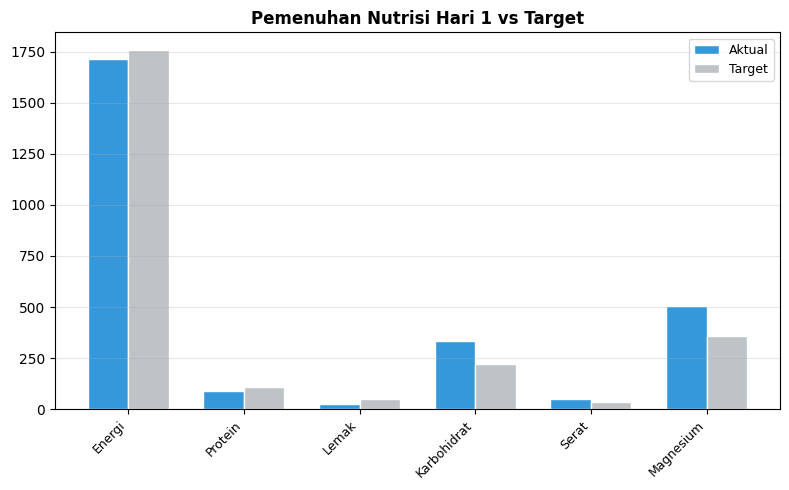

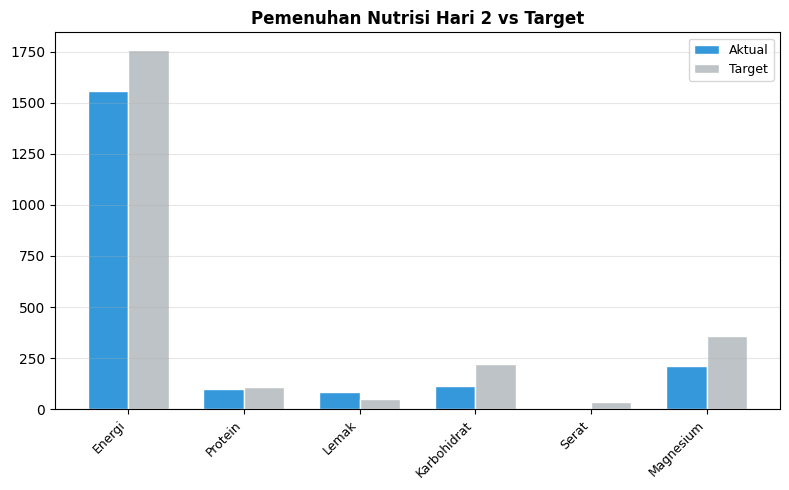

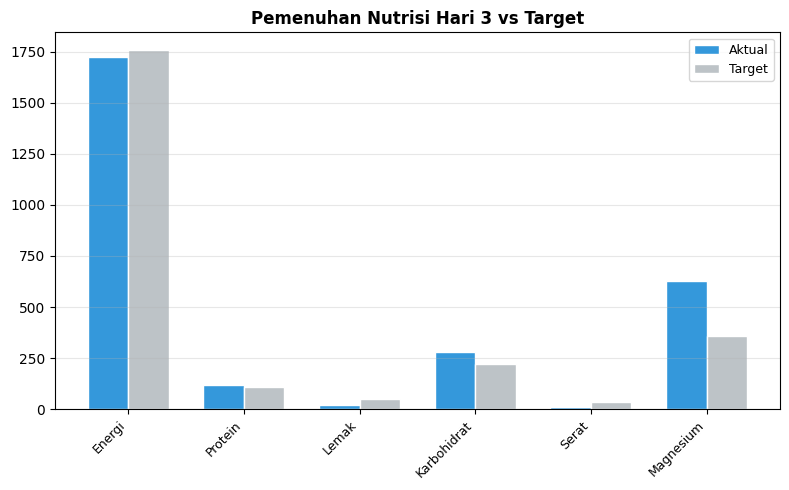

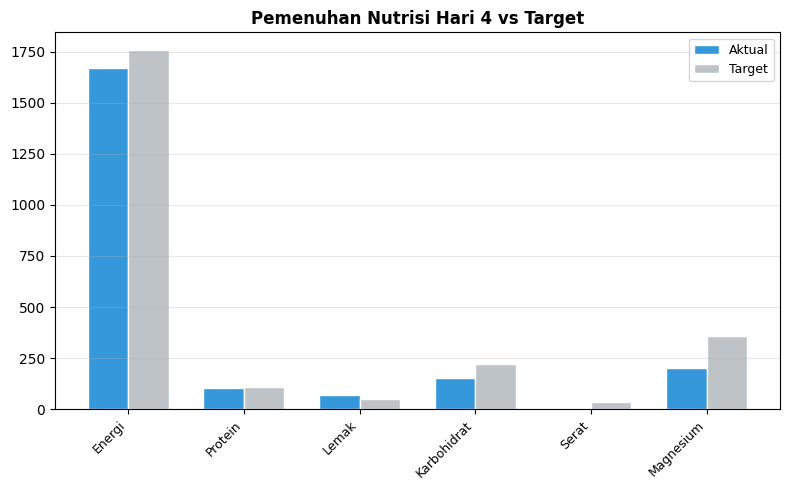

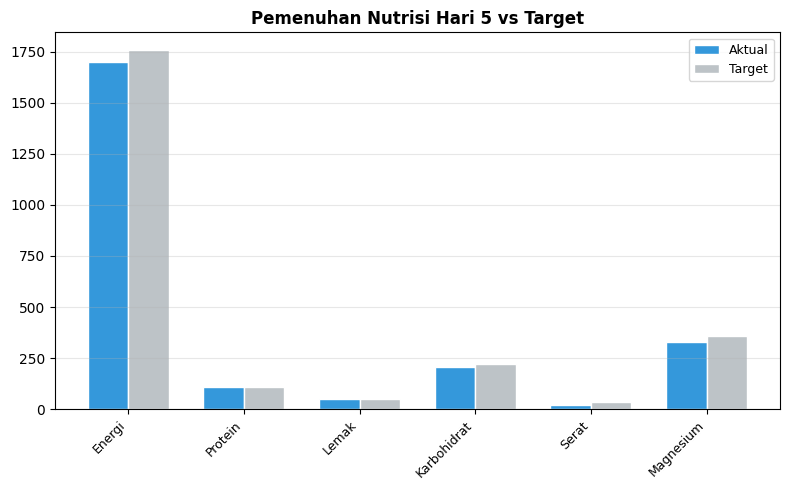

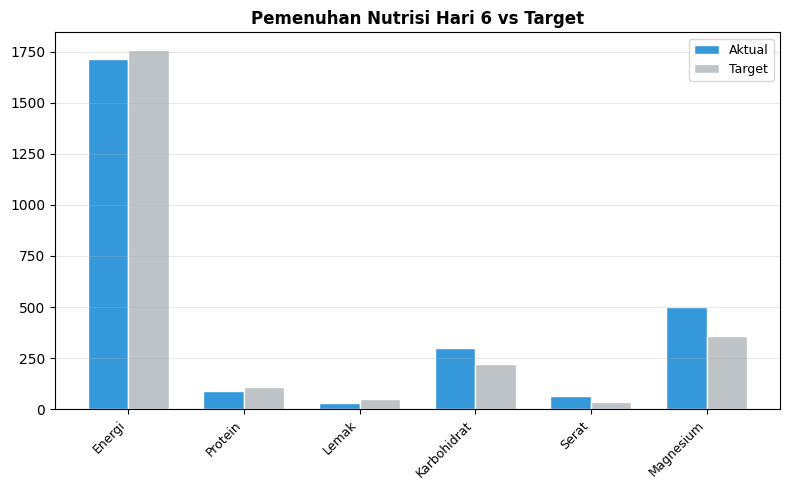

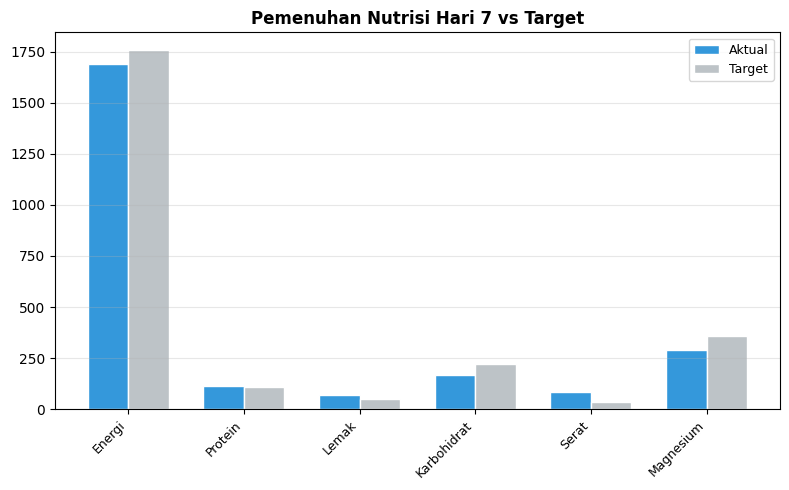


    EVALUASI MEAL PLAN
  Target Kalori Harian    : 1757 kkal

  MAPE per Nutrisi (% dari target):
    Energi         : 4.3%
    Protein        : 9.3%
    Lemak          : 43.9%
    Karbohidrat    : 31.8%
    Serat          : 75.6%
    Kalium         : 22.3%
    Kalsium        : 41.2%
    Magnesium      : 38.3%
    Besi           : 108.2%
    VitaminC       : 105.0%
    VitaminD       : 94.1%

  Rata-rata MAPE       : 52.2%

  Detail kalori per hari:
    Hari 1: 1712 kkal (selisih -45 kkal / -2.6%) ✓
    Hari 2: 1558 kkal (selisih -199 kkal / -11.3%) ⚠
    Hari 3: 1726 kkal (selisih -31 kkal / -1.8%) ✓
    Hari 4: 1672 kkal (selisih -85 kkal / -4.8%) ✓
    Hari 5: 1700 kkal (selisih -57 kkal / -3.2%) ✓
    Hari 6: 1715 kkal (selisih -42 kkal / -2.4%) ✓
    Hari 7: 1692 kkal (selisih -65 kkal / -3.7%) ✓


In [115]:
def main():
    # Memproses data pengguna
    gender          = 'laki-laki'
    age             = 40
    height          = 175
    weight          = 110
    activity_level  = 'sedentary'
    target_weight   = 90
    duration_months = 8.0

    user_input = process_user_data(
        gender          = gender,
        age             = age,
        height          = height,
        weight          = weight,
        activity_level  = activity_level,
        target_weight   = target_weight,
        duration_months = duration_months
    )

    if not user_input['is_valid']:
        for w in user_input['warnings']:
            print(f"  - {w}")
        if user_input['suggestion']:
            print(f"  Saran: {user_input['suggestion']}")
        return

    nutrition_req = user_input['nutrition_req']

    # Tampilkan informasi pengguna
    display_user_info(user_input, nutrition_req)

    # Generate meal plan KNN + Knapsack 0/1
    meal_plan = generate_meal_plan( 
        nutrition_req   = nutrition_req,
        df_preprocessed = df_preprocessed,
        df_original     = df_original,
        scaler          = scaler,
        nutrient_cols   = nutrient_cols,
        days            = 7
    )

    # Tampilkan rekomendasi makanan
    display_meal_plan(meal_plan, nutrition_req)

    # Export ke CSV
    meal_plan_df = export_meal_plan_to_df(meal_plan)

    # Evaluasi meal plan
    comparison = visualize_nutrition_comparison(meal_plan_df, nutrition_req)
    
    evaluate_meal_plan(meal_plan_df, nutrition_req, nutrition_req['Energi'])


if __name__ == "__main__":
    main()